# CSE440 Lab Project - Multi-Class Text Classification

This notebook is revised to follow the **Lab 1 to Lab 4 flow** more closely while still completing the full project requirements from the project brief.

What is included:
- **EDA** with graphs and word clouds
- **three preprocessing versions**: raw, extreme, optimum
- **TF-IDF** with **one ML model** and **one Deep Neural Network**
- **Skip-gram** with **SimpleRNN, GRU, LSTM, Bidirectional SimpleRNN, Bidirectional GRU, Bidirectional LSTM**
- **different hyperparameters** across preprocessing versions and models
- **saved histories, checkpoints, reports, confusion matrices, and one experiment history table**
- **cached preprocessing files** so reruns can skip repeated work

This keeps the implementation simple, avoids optional items, and keeps the notebook organized like an extension of the lab notebooks.

## 1. Module Import

The notebook uses the same overall course flow as the labs:
- **Lab 1** style EDA and preprocessing
- **Lab 2** style word representations
- **Lab 3** style ML and Deep NN structure
- **Lab 4** style sequence model grouping

The neural models are kept in **PyTorch** so CUDA can be used on systems where TensorFlow GPU support is unavailable.

In [4]:
import os
import re
import json
import html
import math
import time
import copy
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from wordcloud import WordCloud
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from nltk.stem import PorterStemmer

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

In [5]:
SEED = 440
VAL_SIZE = 0.15
BATCH_SIZE_TFIDF = 256
DEFAULT_PATIENCE = 2
WORKERS = min(8, os.cpu_count() or 2)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int = SEED) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print("Device:", DEVICE)
print("Seed:", SEED)

Device: cuda
Seed: 440


In [6]:
def find_project_dir() -> Path:
    candidate_dirs = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/mnt/data/cse440_project_artifacts"),
        Path("/mnt/data"),
    ]

    for candidate in candidate_dirs:
        if (candidate / "processed_data").exists():
            return candidate

    for candidate in candidate_dirs:
        if (candidate / "Training_data_4.csv").exists():
            return candidate

    return Path.cwd()

def find_file(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path.cwd().parent / filename,
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}")

TRAIN_PATH = find_file("Training_data_4.csv")
TEST_PATH = find_file("Test_data.csv")

PROJECT_DIR = find_project_dir()
PROCESSED_DIR = PROJECT_DIR / "processed_data"
VECTORIZER_DIR = PROJECT_DIR / "vectorizers"
WORD2VEC_DIR = PROJECT_DIR / "word2vec_models"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
HISTORY_DIR = PROJECT_DIR / "histories"
REPORT_DIR = PROJECT_DIR / "reports"
PLOT_DIR = PROJECT_DIR / "plots"
RESULT_DIR = PROJECT_DIR / "results"
SPLIT_DIR = PROJECT_DIR / "split_cache"

for folder in [
    PROCESSED_DIR,
    VECTORIZER_DIR,
    WORD2VEC_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    REPORT_DIR,
    PLOT_DIR,
    RESULT_DIR,
    SPLIT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Training file:", TRAIN_PATH)
print("Testing file:", TEST_PATH)

Project directory: f:\Coding\Projects\440 temp proj\cse440_project_artifacts_revised
Training file: f:\Coding\Projects\440 temp proj\cse440_project_artifacts_revised\Training_data_4.csv
Testing file: f:\Coding\Projects\440 temp proj\cse440_project_artifacts_revised\Test_data.csv


## 2. Load Dataset

The train split is used for training and validation.  
The given test split is kept only for the final evaluation, matching the project instructions.

In [7]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

assert {"News Headline", "News Topic"}.issubset(train_df.columns)
assert {"News Headline", "News Topic"}.issubset(test_df.columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())
display(train_df["News Topic"].value_counts())

print(train_df.isna().sum())
print(test_df.isna().sum())

Train shape: (104763, 2)
Test shape: (12000, 2)


,News Headline,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Hug...,World News
1,<html> <body> News Headlines:\r\n <br> <b> Mic...,Science and Technology
2,<html> <body> News Headlines:\r\n <br> <b> Gor...,Science and Technology
3,<html> <body> News Headlines:\r\n <br> <b> U.S...,Business
4,<html> <body> News Headlines:\r\n <br> <b> Non...,Business


News Topic
Science and Technology    36428
Sports                    34178
Business                  18563
World News                15594
Name: count, dtype: int64

News Headline    0
News Topic       0
dtype: int64
News Headline    0
News Topic       0
dtype: int64


## 3. Exploratory Data Analysis

This section follows the basic style of **Lab 1**:
- inspect the dataset
- examine class balance
- inspect headline lengths
- create word clouds
- use the observations to justify the preprocessing choices

In [8]:
TAG_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
SPACE_RE = re.compile(r"\s+")

def strip_html_text(text: str) -> str:
    text = html.unescape(str(text))
    text = text.replace("\\r", " ").replace("\\n", " ")
    text = TAG_RE.sub(" ", text)
    text = text.replace("\r", " ").replace("\n", " ")
    text = URL_RE.sub(" ", text)
    text = SPACE_RE.sub(" ", text).strip()
    return text

eda_text = train_df["News Headline"].map(strip_html_text)
headline_lengths = eda_text.str.split().str.len()

print("Sample cleaned headlines:")
for row in eda_text.head(3):
    print("-", row[:180], "...")

Sample cleaned headlines:
- News Headlines: Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. ...
- News Headlines: Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out "spam" e-mail to\win over skeptical  ...
- News Headlines: Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died ...


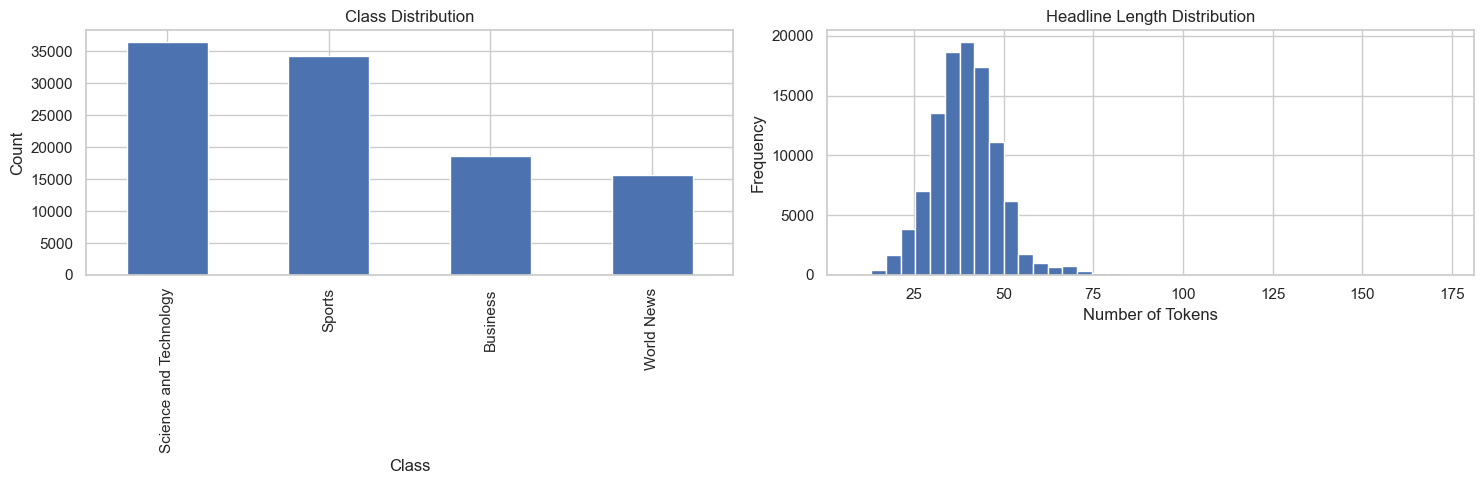

count    104763.000000
mean         39.626213
std          10.361447
min           9.000000
25%          33.000000
50%          39.000000
75%          45.000000
max         173.000000
Name: News Headline, dtype: float64

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

train_df["News Topic"].value_counts().plot(kind="bar", ax=ax[0], title="Class Distribution")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

ax[1].hist(headline_lengths, bins=40)
ax[1].set_title("Headline Length Distribution")
ax[1].set_xlabel("Number of Tokens")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

display(headline_lengths.describe())

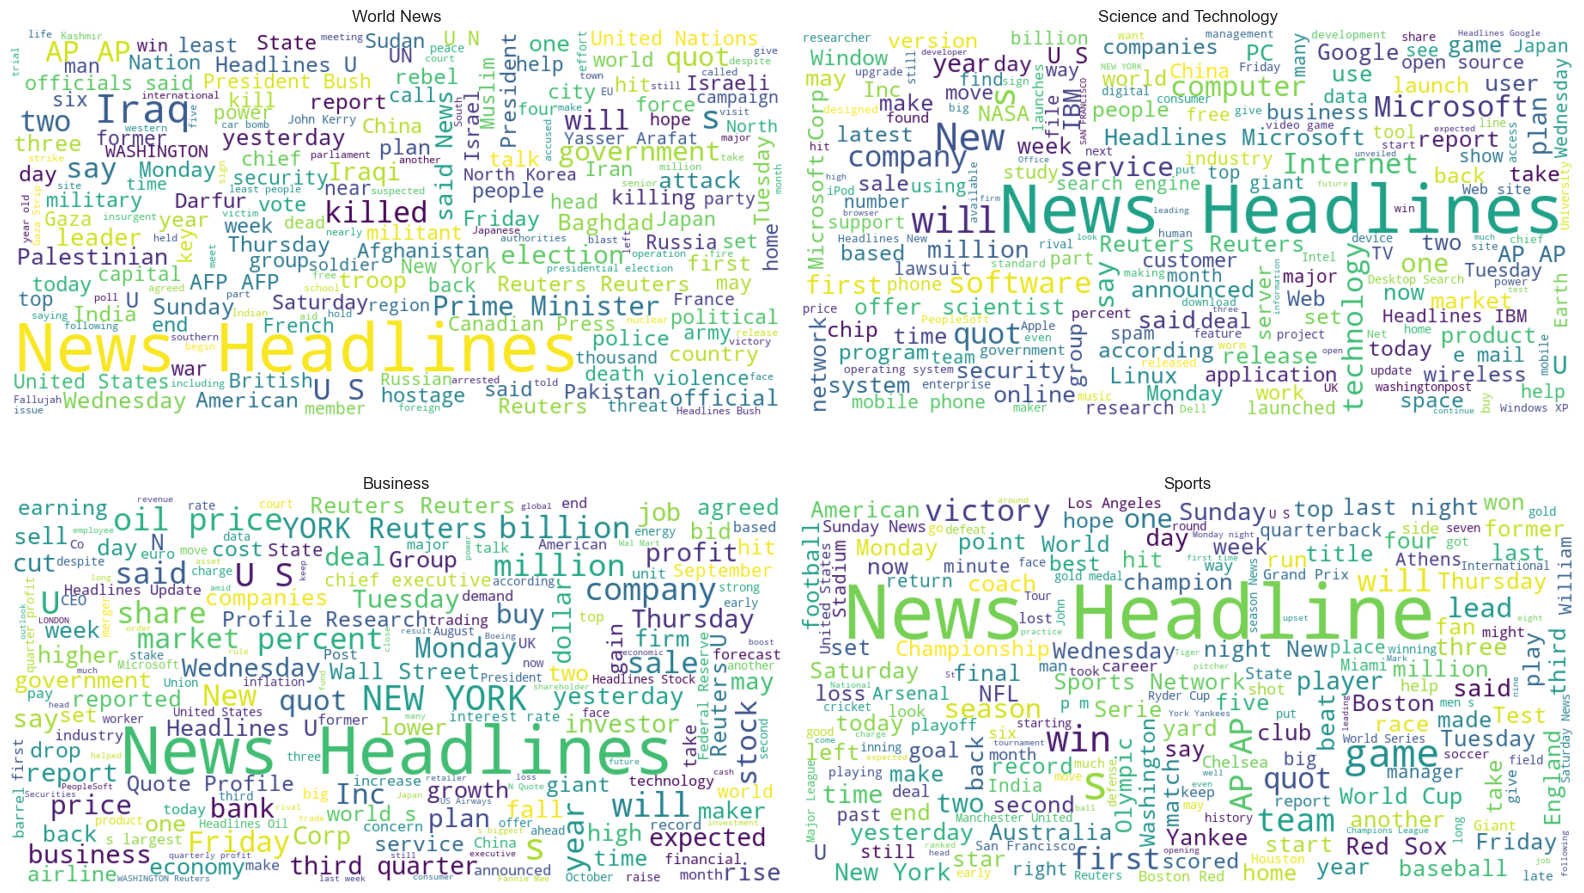

In [10]:
topics = train_df["News Topic"].unique().tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, topic in enumerate(topics):
    topic_text = " ".join(
        eda_text[train_df["News Topic"] == topic].head(2500).tolist()
    )
    wordcloud = WordCloud(
        width=900,
        height=450,
        background_color="white"
    ).generate(topic_text)
    axes[idx].imshow(wordcloud, interpolation="bilinear")
    axes[idx].set_title(topic)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [11]:
clean_token_counts = eda_text.str.lower().str.findall(r"[a-z]+").map(len)
eda_summary = pd.DataFrame({
    "headline_length_words": headline_lengths.describe(),
    "alpha_token_count": clean_token_counts.describe(),
})
display(eda_summary)

topic_share = (
    train_df["News Topic"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .reset_index()
)
display(topic_share)

,headline_length_words,alpha_token_count
count,104763.000000,104763.000000
mean,39.626213,39.525395
std,10.361447,10.387981
min,9.000000,9.000000
25%,33.000000,33.000000
50%,39.000000,39.000000
75%,45.000000,44.000000
max,173.000000,177.000000


,News Topic,percentage
0,Science and Technology,34.77
1,Sports,32.62
2,Business,17.72
3,World News,14.89


## 4. Preprocessing

The project requires three versions of the dataset:
1. **raw**
2. **extreme**
3. **optimum**

The preprocessing files are cached inside `processed_data/` so reruns can skip this part.

In [12]:
stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)
ALPHA_RE = re.compile(r"[a-z]+")
ALNUM_CLEAN_RE = re.compile(r"[^a-z0-9\s]")

def preprocess_raw(text: str) -> str:
    return str(text)

def preprocess_extreme(text: str) -> str:
    text = strip_html_text(text).lower()
    tokens = ALPHA_RE.findall(text)
    tokens = [stemmer.stem(token) for token in tokens if token not in stop_words and len(token) > 1]
    return " ".join(tokens)

def preprocess_optimum(text: str) -> str:
    text = strip_html_text(text).lower()
    text = ALNUM_CLEAN_RE.sub(" ", text)
    text = SPACE_RE.sub(" ", text).strip()
    return text

PREPROCESSING_FUNCTIONS = {
    "raw": preprocess_raw,
    "extreme": preprocess_extreme,
    "optimum": preprocess_optimum,
}

PREPROCESSING_DESCRIPTIONS = {
    "raw": "Original text without preprocessing",
    "extreme": "HTML removal + lowercasing + stopword removal + stemming",
    "optimum": "HTML removal + lowercasing + punctuation cleanup + keep stopwords and numbers",
}

In [13]:
def build_or_load_processed_split(df: pd.DataFrame, split_name: str, version: str) -> pd.DataFrame:
    output_path = PROCESSED_DIR / f"{version}_{split_name}.csv"
    if output_path.exists():
        print(f"Loaded cached file: {output_path.name}")
        return pd.read_csv(output_path)

    processed = df.copy()
    processed["processed_text"] = processed["News Headline"].map(PREPROCESSING_FUNCTIONS[version])
    processed.to_csv(output_path, index=False)
    print(f"Created cached file: {output_path.name}")
    return processed

processed_data = {}
for version in ["raw", "extreme", "optimum"]:
    processed_train = build_or_load_processed_split(train_df, "train", version)
    processed_test = build_or_load_processed_split(test_df, "test", version)
    processed_data[version] = {
        "train": processed_train,
        "test": processed_test,
    }

for version in processed_data:
    print(version, processed_data[version]["train"][["processed_text"]].head(2).to_dict("records"))

Created cached file: raw_train.csv
Created cached file: raw_test.csv
Created cached file: extreme_train.csv
Created cached file: extreme_test.csv
Created cached file: optimum_train.csv
Created cached file: optimum_test.csv
raw [{'processed_text': "<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br> "}, {'processed_text': '<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp.  on Monday\\said it had revised its proposal to weed out "spam" e-mail to\\win over skeptical Internet engineers who have been reluctant\\to adopt technology owned by the dominant software company. </b> \r\n <br> <br> '}]
extreme [{'processed_text': 'news headlin huge boost darfur aid effort world food programm start airlift ton food day sudan troubl darfur region'}, {'processed_text': 'news head

In [14]:
sample_id = 0
preview_df = pd.DataFrame({
    "original": [train_df.loc[sample_id, "News Headline"]],
    "raw": [processed_data["raw"]["train"].loc[sample_id, "processed_text"]],
    "extreme": [processed_data["extreme"]["train"].loc[sample_id, "processed_text"]],
    "optimum": [processed_data["optimum"]["train"].loc[sample_id, "processed_text"]],
})
display(preview_df.T)

preprocess_length_df = pd.DataFrame({
    version: processed_data[version]["train"]["processed_text"].fillna("").str.split().str.len().describe()
    for version in ["raw", "extreme", "optimum"]
}).T
display(preprocess_length_df)

,0
original,<html> <body> News Headlines:\r\n <br> <b> Hug...
raw,<html> <body> News Headlines:\r\n <br> <b> Hug...
extreme,news headlin huge boost darfur aid effort worl...
optimum,news headlines huge boost to darfur aid effort...


,count,mean,std,min,25%,50%,75%,max
raw,104763.0,46.677701,10.393169,17.0,40.0,46.0,52.0,180.0
extreme,104763.0,25.297386,6.174649,7.0,21.0,25.0,29.0,90.0
optimum,104763.0,40.869706,10.738187,9.0,34.0,40.0,46.0,177.0


### 4.1 Train and Validation Split

A fixed seed is used and the train split is divided again into train and validation sets using stratification.

In [15]:
split_path = SPLIT_DIR / "train_val_indices.npz"

if split_path.exists():
    split_cache = np.load(split_path)
    train_idx = split_cache["train_idx"]
    val_idx = split_cache["val_idx"]
else:
    full_indices = np.arange(len(train_df))
    train_idx, val_idx = train_test_split(
        full_indices,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=train_df["News Topic"],
    )
    np.savez(split_path, train_idx=train_idx, val_idx=val_idx)

print("Train split size:", len(train_idx))
print("Validation split size:", len(val_idx))

Train split size: 89048
Validation split size: 15715


In [16]:
split_overview = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_idx), len(val_idx), len(test_df)],
})
display(split_overview)

train_label_counts = train_df.loc[train_idx, "News Topic"].value_counts().rename("train")
val_label_counts = train_df.loc[val_idx, "News Topic"].value_counts().rename("validation")
split_label_table = pd.concat([train_label_counts, val_label_counts], axis=1).fillna(0).astype(int)
display(split_label_table)

,split,rows
0,train,89048
1,validation,15715
2,test,12000


,train,validation
News Topic,,
Science and Technology,30964,5464
Sports,29051,5127
Business,15778,2785
World News,13255,2339


In [17]:
label_encoder = LabelEncoder()
label_encoder.fit(train_df["News Topic"])

label_names = label_encoder.classes_.tolist()
num_classes = len(label_names)

y_train_full = label_encoder.transform(train_df["News Topic"])
y_test = label_encoder.transform(test_df["News Topic"])

y_train = y_train_full[train_idx]
y_val = y_train_full[val_idx]

print("Labels:", label_names)
print("Number of classes:", num_classes)

Labels: ['Business', 'Science and Technology', 'Sports', 'World News']
Number of classes: 4


## 5. Shared Helpers for Evaluation, History, and Saving Outputs

Every run saves:
- checkpoint
- classification report
- confusion matrix
- history for neural models
- one row in the experiment history table

In [18]:
def save_json(data, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2)

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
    return acc, macro_f1, cm, report_dict

def save_confusion_matrix(cm, run_name: str) -> Path:
    path = PLOT_DIR / f"{run_name}_confusion_matrix.png"
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
    )
    plt.title(f"Confusion Matrix - {run_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    return path

def save_report(report_dict, run_name: str) -> Path:
    path = REPORT_DIR / f"{run_name}_classification_report.csv"
    pd.DataFrame(report_dict).transpose().to_csv(path)
    return path

def save_history_plot(history_df: pd.DataFrame, run_name: str) -> Path:
    path = PLOT_DIR / f"{run_name}_history.png"
    plt.figure(figsize=(10, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    if "train_f1" in history_df.columns and "val_f1" in history_df.columns:
        plt.plot(history_df["epoch"], history_df["train_f1"], label="train_f1")
        plt.plot(history_df["epoch"], history_df["val_f1"], label="val_f1")
    plt.title(f"Training History - {run_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    return path

RESULTS_PATH = RESULT_DIR / "experiment_history.csv"
if RESULTS_PATH.exists():
    experiment_rows = pd.read_csv(RESULTS_PATH).to_dict("records")
else:
    experiment_rows = []

def update_experiment_history(row: dict) -> None:
    global experiment_rows
    experiment_rows = [item for item in experiment_rows if item["run_name"] != row["run_name"]]
    experiment_rows.append(row)
    pd.DataFrame(experiment_rows).sort_values(
        by=["representation", "preprocessing", "model"]
    ).to_csv(RESULTS_PATH, index=False)

def run_already_finished(run_name: str) -> bool:
    existing_names = {item["run_name"] for item in experiment_rows}
    return run_name in existing_names

In [19]:
class SparseTFIDFDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.tocsr()
        self.y = np.asarray(y, dtype=np.int64)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return idx, self.y[idx]

def make_tfidf_collate(dataset):
    def collate(batch):
        row_idx = [item[0] for item in batch]
        labels = np.array([item[1] for item in batch], dtype=np.int64)
        dense_batch = dataset.X[row_idx].toarray().astype(np.float32)
        return torch.from_numpy(dense_batch), torch.from_numpy(labels)
    return collate

class TFIDFDNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropouts, num_classes):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_dim, dropout in zip(hidden_dims, dropouts):
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.Dropout(dropout))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x, lengths=None):
        return self.network(x)

In [20]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for batch in loader:
        if len(batch) == 2:
            inputs, labels = batch
            lengths = None
        else:
            inputs, lengths, labels = batch
            lengths = lengths.to(DEVICE)

        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            outputs = model(inputs, lengths)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        predictions = outputs.argmax(dim=1).detach().cpu().numpy()
        all_predictions.extend(predictions.tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro")
    return epoch_loss, epoch_acc, epoch_f1

def train_torch_model(model, train_loader, val_loader, run_name, epochs, lr, patience=DEFAULT_PATIENCE):
    checkpoint_path = CHECKPOINT_DIR / f"{run_name}.pt"
    history_path = HISTORY_DIR / f"{run_name}_history.csv"

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_f1 = -1.0
    best_state = None
    history_rows = []
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion, optimizer=None)

        history_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
        })

        print(
            f"{run_name} | epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | train_f1={train_f1:.4f} | "
            f"val_loss={val_loss:.4f} | val_f1={val_f1:.4f}"
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered for {run_name}")
            break

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(history_path, index=False)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history_df, checkpoint_path, history_path

def predict_torch_model(model, loader):
    model.eval()
    predictions = []
    labels_list = []

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 2:
                inputs, labels = batch
                lengths = None
            else:
                inputs, lengths, labels = batch
                lengths = lengths.to(DEVICE)

            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(inputs, lengths)
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            predictions.extend(preds.tolist())
            labels_list.extend(labels.detach().cpu().numpy().tolist())

    return np.array(labels_list), np.array(predictions)

In [21]:
def get_text_splits(version: str):
    version_train = processed_data[version]["train"]
    version_test = processed_data[version]["test"]

    x_train = version_train.loc[train_idx, "processed_text"].fillna("").tolist()
    x_val = version_train.loc[val_idx, "processed_text"].fillna("").tolist()
    x_test = version_test["processed_text"].fillna("").tolist()

    return x_train, x_val, x_test

def build_tfidf_assets(version: str, x_train, x_val, x_test):
    vectorizer_path = VECTORIZER_DIR / f"{version}_tfidf_vectorizer.pkl"
    if vectorizer_path.exists():
        with open(vectorizer_path, "rb") as handle:
            vectorizer = pickle.load(handle)
    else:
        vectorizer = TfidfVectorizer(**TFIDF_CONFIGS[version])
        vectorizer.fit(x_train)
        with open(vectorizer_path, "wb") as handle:
            pickle.dump(vectorizer, handle)

    X_train = vectorizer.transform(x_train)
    X_val = vectorizer.transform(x_val)
    X_test = vectorizer.transform(x_test)

    return vectorizer, X_train, X_val, X_test, vectorizer_path

## 6. Word Representation 1: TF-IDF

This section follows the **Lab 2 + Lab 3** style:
- build TF-IDF vectors
- train one ML model
- train one Deep Neural Network
- compare the results for all three preprocessing versions

In [22]:
TFIDF_CONFIGS = {
    "raw": {
        "max_features": 25000,
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.98,
        "sublinear_tf": True,
    },
    "extreme": {
        "max_features": 18000,
        "ngram_range": (1, 2),
        "min_df": 3,
        "max_df": 0.97,
        "sublinear_tf": True,
    },
    "optimum": {
        "max_features": 22000,
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.99,
        "sublinear_tf": True,
    },
}

LOGREG_CONFIGS = {
    "raw": {"C": 1.8, "solver": "lbfgs", "max_iter": 700},
    "extreme": {"C": 1.1, "solver": "lbfgs", "max_iter": 800},
    "optimum": {"C": 1.5, "solver": "lbfgs", "max_iter": 750},
}

DNN_CONFIGS = {
    "raw": {
        "hidden_dims": [512, 256, 128],
        "dropouts": [0.35, 0.25, 0.15],
        "lr": 0.0010,
        "batch_size": 256,
        "epochs": 12,
    },
    "extreme": {
        "hidden_dims": [384, 192, 128],
        "dropouts": [0.30, 0.20, 0.15],
        "lr": 0.0008,
        "batch_size": 256,
        "epochs": 12,
    },
    "optimum": {
        "hidden_dims": [512, 256, 128, 64],
        "dropouts": [0.30, 0.25, 0.20, 0.10],
        "lr": 0.0007,
        "batch_size": 256,
        "epochs": 14,
    },
}

save_json(TFIDF_CONFIGS, RESULT_DIR / "tfidf_configs.json")
save_json(LOGREG_CONFIGS, RESULT_DIR / "logreg_configs.json")
save_json(DNN_CONFIGS, RESULT_DIR / "dnn_configs.json")

display(pd.DataFrame(TFIDF_CONFIGS).transpose())
display(pd.DataFrame(LOGREG_CONFIGS).transpose())
display(pd.DataFrame(DNN_CONFIGS).transpose())

,max_features,ngram_range,min_df,max_df,sublinear_tf
raw,25000,"(1, 2)",2,0.98,True
extreme,18000,"(1, 2)",3,0.97,True
optimum,22000,"(1, 2)",2,0.99,True


,C,solver,max_iter
raw,1.8,lbfgs,700
extreme,1.1,lbfgs,800
optimum,1.5,lbfgs,750


,hidden_dims,dropouts,lr,batch_size,epochs
raw,"[512, 256, 128]","[0.35, 0.25, 0.15]",0.001,256,12
extreme,"[384, 192, 128]","[0.3, 0.2, 0.15]",0.0008,256,12
optimum,"[512, 256, 128, 64]","[0.3, 0.25, 0.2, 0.1]",0.0007,256,14


In [23]:
tfidf_assets = {}

for version in ["raw", "extreme", "optimum"]:
    x_train, x_val, x_test = get_text_splits(version)
    vectorizer, X_train, X_val, X_test, vectorizer_path = build_tfidf_assets(version, x_train, x_val, x_test)
    tfidf_assets[version] = {
        "vectorizer": vectorizer,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "vectorizer_path": vectorizer_path,
    }

tfidf_shape_table = pd.DataFrame({
    version: {
        "train_rows": tfidf_assets[version]["X_train"].shape[0],
        "train_features": tfidf_assets[version]["X_train"].shape[1],
        "val_rows": tfidf_assets[version]["X_val"].shape[0],
        "test_rows": tfidf_assets[version]["X_test"].shape[0],
    }
    for version in ["raw", "extreme", "optimum"]
}).T
display(tfidf_shape_table)

,train_rows,train_features,val_rows,test_rows
raw,89048,25000,15715,12000
extreme,89048,18000,15715,12000
optimum,89048,22000,15715,12000


### 6.1 Logistic Regression

In [24]:
def run_logistic_regression(version: str, X_train, X_val, X_test):
    run_name = f"{version}_tfidf_logistic_regression"
    if run_already_finished(run_name):
        print(f"Skipping finished run: {run_name}")
        return

    model = LogisticRegression(random_state=SEED, **LOGREG_CONFIGS[version])
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_acc, val_f1, _, _ = compute_metrics(y_val, val_pred)
    test_acc, test_f1, test_cm, test_report = compute_metrics(y_test, test_pred)

    model_path = CHECKPOINT_DIR / f"{run_name}.pkl"
    with open(model_path, "wb") as handle:
        pickle.dump(model, handle)

    cm_path = save_confusion_matrix(test_cm, run_name)
    report_path = save_report(test_report, run_name)

    row = {
        "run_name": run_name,
        "preprocessing": version,
        "representation": "TF-IDF",
        "model": "Logistic Regression",
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "checkpoint_path": str(model_path),
        "history_path": "",
        "report_path": str(report_path),
        "confusion_matrix_path": str(cm_path),
        "hyperparameters": json.dumps(LOGREG_CONFIGS[version]),
    }
    update_experiment_history(row)
    print(pd.DataFrame([row]))

In [25]:
for version in ["raw", "extreme", "optimum"]:
    print("\n" + "=" * 90)
    print(f"Running Logistic Regression for: {version}")
    X_train = tfidf_assets[version]["X_train"]
    X_val = tfidf_assets[version]["X_val"]
    X_test = tfidf_assets[version]["X_test"]
    run_logistic_regression(version, X_train, X_val, X_test)


Running Logistic Regression for: raw
                        run_name preprocessing representation  \
0  raw_tfidf_logistic_regression           raw         TF-IDF   

                 model  val_accuracy  val_macro_f1  test_accuracy  \
0  Logistic Regression      0.942412      0.931079       0.888333   

   test_macro_f1                                    checkpoint_path  \
0       0.888684  f:\Coding\Projects\440 temp proj\cse440_projec...   

  history_path                                        report_path  \
0               f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                  hyperparameters  
0  {"C": 1.8, "solver": "lbfgs", "max_iter": 700}  

Running Logistic Regression for: extreme
                            run_name preprocessing representation  \
0  extreme_tfidf_logistic_regression       extreme         TF-IDF   

            

### 6.2 Deep Neural Network

In [26]:
def run_tfidf_dnn(version: str, X_train, X_val, X_test):
    run_name = f"{version}_tfidf_deep_nn"
    if run_already_finished(run_name):
        print(f"Skipping finished run: {run_name}")
        return

    config = DNN_CONFIGS[version]

    train_dataset = SparseTFIDFDataset(X_train, y_train)
    val_dataset = SparseTFIDFDataset(X_val, y_val)
    test_dataset = SparseTFIDFDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        collate_fn=make_tfidf_collate(train_dataset),
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        collate_fn=make_tfidf_collate(val_dataset),
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        collate_fn=make_tfidf_collate(test_dataset),
    )

    model = TFIDFDNN(
        input_dim=X_train.shape[1],
        hidden_dims=config["hidden_dims"],
        dropouts=config["dropouts"],
        num_classes=num_classes,
    ).to(DEVICE)

    model, history_df, checkpoint_path, history_path = train_torch_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        run_name=run_name,
        epochs=config["epochs"],
        lr=config["lr"],
        patience=DEFAULT_PATIENCE,
    )

    _, val_pred = predict_torch_model(model, val_loader)
    _, test_pred = predict_torch_model(model, test_loader)

    val_acc, val_f1, _, _ = compute_metrics(y_val, val_pred)
    test_acc, test_f1, test_cm, test_report = compute_metrics(y_test, test_pred)

    report_path = save_report(test_report, run_name)
    cm_path = save_confusion_matrix(test_cm, run_name)
    history_plot_path = save_history_plot(history_df, run_name)

    row = {
        "run_name": run_name,
        "preprocessing": version,
        "representation": "TF-IDF",
        "model": "Deep NN",
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "checkpoint_path": str(checkpoint_path),
        "history_path": str(history_path),
        "report_path": str(report_path),
        "confusion_matrix_path": str(cm_path),
        "history_plot_path": str(history_plot_path),
        "hyperparameters": json.dumps(config),
    }
    update_experiment_history(row)
    display(history_df.tail())
    print(pd.DataFrame([row]))

In [27]:
for version in ["raw", "extreme", "optimum"]:
    print("\n" + "=" * 90)
    print(f"Running Deep Neural Network for: {version}")
    X_train = tfidf_assets[version]["X_train"]
    X_val = tfidf_assets[version]["X_val"]
    X_test = tfidf_assets[version]["X_test"]
    run_tfidf_dnn(version, X_train, X_val, X_test)


Running Deep Neural Network for: raw
raw_tfidf_deep_nn | epoch 01/12 | train_loss=0.2571 | train_f1=0.9009 | val_loss=0.1821 | val_f1=0.9300
raw_tfidf_deep_nn | epoch 02/12 | train_loss=0.0912 | train_f1=0.9631 | val_loss=0.2058 | val_f1=0.9333
raw_tfidf_deep_nn | epoch 03/12 | train_loss=0.0381 | train_f1=0.9834 | val_loss=0.2666 | val_f1=0.9297
raw_tfidf_deep_nn | epoch 04/12 | train_loss=0.0259 | train_f1=0.9887 | val_loss=0.2989 | val_f1=0.9283
Early stopping triggered for raw_tfidf_deep_nn


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.257101,0.915888,0.900862,0.182114,0.942030,0.929957
1,2,0.091229,0.969005,0.963126,0.205823,0.944830,0.933324
2,3,0.038143,0.986165,0.983440,0.266571,0.942221,0.929727
3,4,0.025930,0.990522,0.988733,0.298891,0.941266,0.928262


            run_name preprocessing representation    model  val_accuracy  \
0  raw_tfidf_deep_nn           raw         TF-IDF  Deep NN       0.94483   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.933324         0.8945       0.894299   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"hidden_dims": [512, 256, 128], "dropouts": [...  

Running Deep Neural Network for: extreme
extreme_tfidf_deep_nn | epoch 0

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.257301,0.915529,0.901096,0.182999,0.941457,0.930630
1,2,0.108591,0.962593,0.955252,0.190685,0.945148,0.934399
2,3,0.054208,0.980134,0.976508,0.245110,0.943493,0.932189
3,4,0.035211,0.986760,0.984358,0.283990,0.941139,0.929402


                run_name preprocessing representation    model  val_accuracy  \
0  extreme_tfidf_deep_nn       extreme         TF-IDF  Deep NN      0.945148   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.934399       0.912667       0.912453   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"hidden_dims": [384, 192, 128], "dropouts": [...  

Running Deep Neural Network for: optimum
optimum_tfidf_deep_nn |

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.289205,0.907039,0.890612,0.188351,0.939739,0.927580
1,2,0.109816,0.964514,0.957591,0.205278,0.941712,0.929576
2,3,0.052215,0.981684,0.978259,0.258955,0.939930,0.927174
3,4,0.035141,0.987220,0.984890,0.287939,0.939612,0.926596


                run_name preprocessing representation    model  val_accuracy  \
0  optimum_tfidf_deep_nn       optimum         TF-IDF  Deep NN      0.941712   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.929576       0.904833       0.904618   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"hidden_dims": [512, 256, 128, 64], "dropouts...  


## 7. Word Representation 2: Skip-gram

This section follows the **Lab 2 + Lab 4** structure:
- train or load a skip-gram Word2Vec model
- convert each text into sequences
- pad the sequences
- train the required RNN-family models

In [28]:
WORD2VEC_CONFIGS = {
    "raw": {"vector_size": 120, "window": 5, "min_count": 2, "epochs": 10, "negative": 10, "max_len": 60},
    "extreme": {"vector_size": 100, "window": 4, "min_count": 2, "epochs": 12, "negative": 8, "max_len": 40},
    "optimum": {"vector_size": 140, "window": 5, "min_count": 2, "epochs": 10, "negative": 10, "max_len": 50},
}

SEQUENCE_MODEL_CONFIGS = {
    "SimpleRNN": {
        "raw": {"cell_type": "rnn", "bidirectional": False, "hidden_dim": 96, "fc_dim": 64, "dropout": 0.25, "lr": 0.0010, "batch_size": 128, "epochs": 7},
        "extreme": {"cell_type": "rnn", "bidirectional": False, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.0011, "batch_size": 128, "epochs": 7},
        "optimum": {"cell_type": "rnn", "bidirectional": False, "hidden_dim": 112, "fc_dim": 64, "dropout": 0.25, "lr": 0.0009, "batch_size": 128, "epochs": 8},
    },
    "GRU": {
        "raw": {"cell_type": "gru", "bidirectional": False, "hidden_dim": 112, "fc_dim": 64, "dropout": 0.30, "lr": 0.0008, "batch_size": 128, "epochs": 8},
        "extreme": {"cell_type": "gru", "bidirectional": False, "hidden_dim": 96, "fc_dim": 64, "dropout": 0.30, "lr": 0.0009, "batch_size": 128, "epochs": 8},
        "optimum": {"cell_type": "gru", "bidirectional": False, "hidden_dim": 128, "fc_dim": 64, "dropout": 0.25, "lr": 0.0007, "batch_size": 128, "epochs": 9},
    },
    "LSTM": {
        "raw": {"cell_type": "lstm", "bidirectional": False, "hidden_dim": 112, "fc_dim": 64, "dropout": 0.35, "lr": 0.0008, "batch_size": 128, "epochs": 8},
        "extreme": {"cell_type": "lstm", "bidirectional": False, "hidden_dim": 96, "fc_dim": 64, "dropout": 0.30, "lr": 0.00085, "batch_size": 128, "epochs": 8},
        "optimum": {"cell_type": "lstm", "bidirectional": False, "hidden_dim": 128, "fc_dim": 80, "dropout": 0.25, "lr": 0.0007, "batch_size": 128, "epochs": 9},
    },
    "BiSimpleRNN": {
        "raw": {"cell_type": "rnn", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.0009, "batch_size": 128, "epochs": 7},
        "extreme": {"cell_type": "rnn", "bidirectional": True, "hidden_dim": 72, "fc_dim": 64, "dropout": 0.30, "lr": 0.0010, "batch_size": 128, "epochs": 7},
        "optimum": {"cell_type": "rnn", "bidirectional": True, "hidden_dim": 96, "fc_dim": 64, "dropout": 0.25, "lr": 0.0008, "batch_size": 128, "epochs": 8},
    },
    "BiGRU": {
        "raw": {"cell_type": "gru", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.0008, "batch_size": 128, "epochs": 8},
        "extreme": {"cell_type": "gru", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.00085, "batch_size": 128, "epochs": 8},
        "optimum": {"cell_type": "gru", "bidirectional": True, "hidden_dim": 96, "fc_dim": 80, "dropout": 0.25, "lr": 0.0007, "batch_size": 128, "epochs": 9},
    },
    "BiLSTM": {
        "raw": {"cell_type": "lstm", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.35, "lr": 0.0008, "batch_size": 128, "epochs": 8},
        "extreme": {"cell_type": "lstm", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.0008, "batch_size": 128, "epochs": 8},
        "optimum": {"cell_type": "lstm", "bidirectional": True, "hidden_dim": 96, "fc_dim": 80, "dropout": 0.25, "lr": 0.00065, "batch_size": 128, "epochs": 9},
    },
}

save_json(WORD2VEC_CONFIGS, RESULT_DIR / "word2vec_configs.json")
save_json(SEQUENCE_MODEL_CONFIGS, RESULT_DIR / "sequence_model_configs.json")

display(pd.DataFrame(WORD2VEC_CONFIGS).transpose())

,vector_size,window,min_count,epochs,negative,max_len
raw,120,5,2,10,10,60
extreme,100,4,2,12,8,40
optimum,140,5,2,10,10,50


In [29]:
def train_or_load_word2vec(version: str, tokenized_train):
    config = WORD2VEC_CONFIGS[version]
    model_path = WORD2VEC_DIR / f"{version}_skipgram.model"

    if model_path.exists():
        print(f"Loaded Word2Vec model: {model_path.name}")
        return Word2Vec.load(str(model_path)), model_path

    print(f"Training Word2Vec for: {version}")
    w2v_model = Word2Vec(
        sentences=tokenized_train,
        vector_size=config["vector_size"],
        window=config["window"],
        min_count=config["min_count"],
        workers=WORKERS,
        sg=1,
        negative=config["negative"],
        epochs=config["epochs"],
        seed=SEED,
    )
    w2v_model.save(str(model_path))
    return w2v_model, model_path

def build_word_index_and_embeddings(w2v_model):
    vocab = w2v_model.wv.index_to_key
    word_index = {word: idx + 2 for idx, word in enumerate(vocab)}
    embedding_dim = w2v_model.wv.vector_size
    embedding_matrix = np.zeros((len(vocab) + 2, embedding_dim), dtype=np.float32)

    for word, idx in word_index.items():
        embedding_matrix[idx] = w2v_model.wv[word]

    return word_index, embedding_matrix

def texts_to_sequences(texts, word_index):
    sequences = []
    for text in texts:
        tokens = str(text).split()
        sequence = [word_index.get(token, 1) for token in tokens]
        if not sequence:
            sequence = [1]
        sequences.append(sequence)
    return sequences

def pad_sequences_custom(sequences, max_len):
    padded = np.zeros((len(sequences), max_len), dtype=np.int64)
    lengths = np.zeros(len(sequences), dtype=np.int64)
    for idx, sequence in enumerate(sequences):
        clipped = sequence[:max_len]
        length = max(1, len(clipped))
        padded[idx, :length] = clipped[:length]
        lengths[idx] = length
    return padded, lengths

In [30]:
class SequenceDataset(Dataset):
    def __init__(self, padded_sequences, lengths, labels):
        self.padded_sequences = torch.tensor(padded_sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.padded_sequences[idx], self.lengths[idx], self.labels[idx]

class SequenceClassifier(nn.Module):
    def __init__(self, embedding_matrix, cell_type, hidden_dim, fc_dim, dropout, num_classes, bidirectional=False):
        super().__init__()
        embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)
        embedding_dim = embedding_tensor.shape[1]

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=True,
            padding_idx=0,
        )
        self.cell_type = cell_type
        self.bidirectional = bidirectional

        rnn_map = {
            "rnn": nn.RNN,
            "gru": nn.GRU,
            "lstm": nn.LSTM,
        }
        self.encoder = rnn_map[cell_type](
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=bidirectional,
        )

        encoder_output_dim = hidden_dim * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(encoder_output_dim, fc_dim),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(fc_dim, num_classes),
        )

    def forward(self, x, lengths=None):
        embedded = self.embedding(x)
        if lengths is None:
            raise ValueError("lengths must be provided for sequence models")

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_outputs = self.encoder(packed)

        if self.cell_type == "lstm":
            hidden = packed_outputs[1][0]
        else:
            hidden = packed_outputs[1]

        if self.bidirectional:
            final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            final_hidden = hidden[-1]

        return self.classifier(final_hidden)

In [31]:
def prepare_skipgram_assets(version: str):
    x_train, x_val, x_test = get_text_splits(version)

    tokenized_train = [str(text).split() for text in x_train]
    w2v_model, w2v_path = train_or_load_word2vec(version, tokenized_train)

    word_index, embedding_matrix = build_word_index_and_embeddings(w2v_model)

    train_sequences = texts_to_sequences(x_train, word_index)
    val_sequences = texts_to_sequences(x_val, word_index)
    test_sequences = texts_to_sequences(x_test, word_index)

    max_len = WORD2VEC_CONFIGS[version]["max_len"]

    X_train_seq, train_lengths = pad_sequences_custom(train_sequences, max_len)
    X_val_seq, val_lengths = pad_sequences_custom(val_sequences, max_len)
    X_test_seq, test_lengths = pad_sequences_custom(test_sequences, max_len)

    return {
        "embedding_matrix": embedding_matrix,
        "train_dataset": SequenceDataset(X_train_seq, train_lengths, y_train),
        "val_dataset": SequenceDataset(X_val_seq, val_lengths, y_val),
        "test_dataset": SequenceDataset(X_test_seq, test_lengths, y_test),
        "w2v_path": w2v_path,
        "max_len": max_len,
        "vocab_size": embedding_matrix.shape[0],
    }

In [32]:
def run_sequence_model(version: str, model_name: str, assets: dict):
    run_name = f"{version}_skipgram_{model_name.lower()}"
    if run_already_finished(run_name):
        print(f"Skipping finished run: {run_name}")
        return

    config = SEQUENCE_MODEL_CONFIGS[model_name][version]

    train_loader = DataLoader(
        assets["train_dataset"],
        batch_size=config["batch_size"],
        shuffle=True,
    )
    val_loader = DataLoader(
        assets["val_dataset"],
        batch_size=config["batch_size"],
        shuffle=False,
    )
    test_loader = DataLoader(
        assets["test_dataset"],
        batch_size=config["batch_size"],
        shuffle=False,
    )

    model = SequenceClassifier(
        embedding_matrix=assets["embedding_matrix"],
        cell_type=config["cell_type"],
        hidden_dim=config["hidden_dim"],
        fc_dim=config["fc_dim"],
        dropout=config["dropout"],
        num_classes=num_classes,
        bidirectional=config["bidirectional"],
    ).to(DEVICE)

    model, history_df, checkpoint_path, history_path = train_torch_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        run_name=run_name,
        epochs=config["epochs"],
        lr=config["lr"],
        patience=DEFAULT_PATIENCE,
    )

    _, val_pred = predict_torch_model(model, val_loader)
    _, test_pred = predict_torch_model(model, test_loader)

    val_acc, val_f1, _, _ = compute_metrics(y_val, val_pred)
    test_acc, test_f1, test_cm, test_report = compute_metrics(y_test, test_pred)

    report_path = save_report(test_report, run_name)
    cm_path = save_confusion_matrix(test_cm, run_name)
    history_plot_path = save_history_plot(history_df, run_name)

    row = {
        "run_name": run_name,
        "preprocessing": version,
        "representation": "Skip-gram",
        "model": model_name,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "checkpoint_path": str(checkpoint_path),
        "history_path": str(history_path),
        "report_path": str(report_path),
        "confusion_matrix_path": str(cm_path),
        "history_plot_path": str(history_plot_path),
        "hyperparameters": json.dumps(config),
    }
    update_experiment_history(row)
    display(history_df.tail())
    print(pd.DataFrame([row]))

### 7.1 Prepare Skip-gram Assets

In [33]:
skipgram_assets_by_version = {}

for version in ["raw", "extreme", "optimum"]:
    print("\n" + "=" * 90)
    print(f"Preparing skip-gram assets for: {version}")
    skipgram_assets_by_version[version] = prepare_skipgram_assets(version)

skipgram_shape_table = pd.DataFrame({
    version: {
        "vocab_size": skipgram_assets_by_version[version]["vocab_size"],
        "embedding_dim": skipgram_assets_by_version[version]["embedding_matrix"].shape[1],
        "max_len": skipgram_assets_by_version[version]["max_len"],
        "train_rows": len(skipgram_assets_by_version[version]["train_dataset"]),
    }
    for version in ["raw", "extreme", "optimum"]
}).T
display(skipgram_shape_table)


Preparing skip-gram assets for: raw
Training Word2Vec for: raw

Preparing skip-gram assets for: extreme
Training Word2Vec for: extreme

Preparing skip-gram assets for: optimum
Training Word2Vec for: optimum


,vocab_size,embedding_dim,max_len,train_rows
raw,85845,120,60,89048
extreme,26302,100,40,89048
optimum,40080,140,50,89048


### 7.2 SimpleRNN and Bidirectional SimpleRNN

In [34]:
for version in ["raw", "extreme", "optimum"]:
    for model_name in ["SimpleRNN", "BiSimpleRNN"]:
        print("\n" + "-" * 90)
        print(f"Running {model_name} on {version}")
        run_sequence_model(version, model_name, skipgram_assets_by_version[version])


------------------------------------------------------------------------------------------
Running SimpleRNN on raw
raw_skipgram_simplernn | epoch 01/7 | train_loss=0.6622 | train_f1=0.6789 | val_loss=0.5174 | val_f1=0.8006
raw_skipgram_simplernn | epoch 02/7 | train_loss=0.4883 | train_f1=0.8265 | val_loss=0.5502 | val_f1=0.7841
raw_skipgram_simplernn | epoch 03/7 | train_loss=0.6119 | train_f1=0.7197 | val_loss=0.8162 | val_f1=0.5427
Early stopping triggered for raw_skipgram_simplernn


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.662206,0.746013,0.678942,0.517368,0.819790,0.800641
1,2,0.488314,0.849171,0.826528,0.550220,0.795737,0.784138
2,3,0.611856,0.776031,0.719678,0.816201,0.666879,0.542692


                 run_name preprocessing representation      model  \
0  raw_skipgram_simplernn           raw      Skip-gram  SimpleRNN   

   val_accuracy  val_macro_f1  test_accuracy  test_macro_f1  \
0       0.81979      0.800641        0.81125       0.813688   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "rnn", "bidirectional": false, "...  

----------------------------------------------------------

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
1,2,0.360877,0.887083,0.869452,0.329312,0.895768,0.878249
2,3,0.333176,0.893731,0.876949,0.314253,0.897741,0.881403
3,4,0.322164,0.897303,0.880699,0.302892,0.900732,0.886932
4,5,0.310856,0.900177,0.884273,0.340091,0.889787,0.874129
5,6,0.307303,0.901503,0.885809,0.393134,0.864779,0.849164


                   run_name preprocessing representation        model  \
0  raw_skipgram_bisimplernn           raw      Skip-gram  BiSimpleRNN   

   val_accuracy  val_macro_f1  test_accuracy  test_macro_f1  \
0      0.900732      0.886932         0.8805       0.879743   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "rnn", "bidirectional": true, "h...  

--------------------------------------------------

...

                       run_name preprocessing representation        model  \
0  extreme_skipgram_bisimplernn       extreme      Skip-gram  BiSimpleRNN   

   val_accuracy  val_macro_f1  test_accuracy  test_macro_f1  \
0       0.91524      0.900668       0.889083        0.88855   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "rnn", "bidirectional": true, "h...  

------------------------------------------

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.560591,0.809114,0.780408,0.354370,0.889978,0.874136
1,2,0.402534,0.877201,0.858291,0.418224,0.876806,0.850951
2,3,0.413438,0.874921,0.854317,0.393665,0.876869,0.860196


                     run_name preprocessing representation      model  \
0  optimum_skipgram_simplernn       optimum      Skip-gram  SimpleRNN   

   val_accuracy  val_macro_f1  test_accuracy  test_macro_f1  \
0      0.889978      0.874136       0.878417       0.878039   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "rnn", "bidirectional": false, "...  

--------------------------------------------------

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
3,4,0.289160,0.905309,0.890041,0.285174,0.903786,0.889462
4,5,0.282390,0.907005,0.892020,0.313319,0.898632,0.884729
5,6,0.275919,0.909184,0.894195,0.272013,0.908750,0.893649
6,7,0.266375,0.911508,0.896744,0.282825,0.907859,0.889463
7,8,0.262461,0.912407,0.897800,0.316258,0.895959,0.878811


                       run_name preprocessing representation        model  \
0  optimum_skipgram_bisimplernn       optimum      Skip-gram  BiSimpleRNN   

   val_accuracy  val_macro_f1  test_accuracy  test_macro_f1  \
0       0.90875      0.893649        0.89625       0.896106   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "rnn", "bidirectional": true, "h...  


### 7.3 GRU and Bidirectional GRU

In [35]:
for version in ["raw", "extreme", "optimum"]:
    for model_name in ["GRU", "BiGRU"]:
        print("\n" + "-" * 90)
        print(f"Running {model_name} on {version}")
        run_sequence_model(version, model_name, skipgram_assets_by_version[version])


------------------------------------------------------------------------------------------
Running GRU on raw
raw_skipgram_gru | epoch 01/8 | train_loss=0.4035 | train_f1=0.8328 | val_loss=0.2531 | val_f1=0.8999
raw_skipgram_gru | epoch 02/8 | train_loss=0.2469 | train_f1=0.9053 | val_loss=0.2390 | val_f1=0.9062
raw_skipgram_gru | epoch 03/8 | train_loss=0.2246 | train_f1=0.9126 | val_loss=0.2185 | val_f1=0.9124
raw_skipgram_gru | epoch 04/8 | train_loss=0.2091 | train_f1=0.9179 | val_loss=0.2218 | val_f1=0.9117
raw_skipgram_gru | epoch 05/8 | train_loss=0.1985 | train_f1=0.9214 | val_loss=0.2063 | val_f1=0.9147
raw_skipgram_gru | epoch 06/8 | train_loss=0.1862 | train_f1=0.9256 | val_loss=0.2209 | val_f1=0.9125
raw_skipgram_gru | epoch 07/8 | train_loss=0.1738 | train_f1=0.9296 | val_loss=0.1939 | val_f1=0.9215
raw_skipgram_gru | epoch 08/8 | train_loss=0.1635 | train_f1=0.9334 | val_loss=0.1833 | val_f1=0.9287


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
3,4,0.209095,0.930296,0.917935,0.221829,0.923767,0.911746
4,5,0.198482,0.933272,0.921441,0.206275,0.927203,0.914658
5,6,0.186226,0.936989,0.925590,0.220918,0.922813,0.912465
6,7,0.173825,0.940538,0.929551,0.193942,0.932358,0.921512
7,8,0.163543,0.944008,0.933418,0.183290,0.939230,0.928736


           run_name preprocessing representation model  val_accuracy  \
0  raw_skipgram_gru           raw      Skip-gram   GRU       0.93923   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.928736         0.9145       0.914425   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "gru", "bidirectional": false, "...  

--------------------------------------------------------------------------------

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
3,4,0.203173,0.931677,0.919543,0.211703,0.926631,0.914511
4,5,0.188148,0.936326,0.924998,0.197778,0.931339,0.920172
5,6,0.175300,0.940347,0.929620,0.190757,0.934712,0.924630
6,7,0.162423,0.944367,0.934374,0.185824,0.936748,0.925592
7,8,0.149653,0.949016,0.939782,0.183332,0.937830,0.928502


             run_name preprocessing representation  model  val_accuracy  \
0  raw_skipgram_bigru           raw      Skip-gram  BiGRU       0.93783   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.928502       0.917667       0.917627   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "gru", "bidirectional": true, "h...  

--------------------------------------------------------------------------

...

                 run_name preprocessing representation  model  val_accuracy  \
0  extreme_skipgram_bigru       extreme      Skip-gram  BiGRU      0.939294   

   val_macro_f1  test_accuracy  test_macro_f1  \
0       0.92821       0.917083       0.916889   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "gru", "bidirectional": true, "h...  

------------------------------------------------------------------

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
4,5,0.207358,0.929611,0.917118,0.209995,0.929621,0.917066
5,6,0.195477,0.934721,0.923037,0.203718,0.932294,0.920161
6,7,0.183961,0.938426,0.927196,0.197881,0.931785,0.918605
7,8,0.173510,0.942267,0.931581,0.189462,0.937703,0.926166
8,9,0.161904,0.946433,0.936139,0.184994,0.939994,0.929217


               run_name preprocessing representation model  val_accuracy  \
0  optimum_skipgram_gru       optimum      Skip-gram   GRU      0.939994   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.929217          0.917       0.916971   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "gru", "bidirectional": false, "...  

------------------------------------------------------------------------

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
2,3,0.225742,0.924310,0.911160,0.217552,0.927712,0.914971
3,4,0.209842,0.930038,0.917753,0.207858,0.929749,0.918140
4,5,0.196924,0.934058,0.922296,0.200662,0.935221,0.923610
5,6,0.183152,0.938831,0.927641,0.215340,0.927903,0.916849
6,7,0.172073,0.942424,0.931698,0.195815,0.934458,0.921997


                 run_name preprocessing representation  model  val_accuracy  \
0  optimum_skipgram_bigru       optimum      Skip-gram  BiGRU      0.935221   

   val_macro_f1  test_accuracy  test_macro_f1  \
0       0.92361       0.910667       0.910479   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "gru", "bidirectional": true, "h...  


### 7.4 LSTM and Bidirectional LSTM

In [36]:
for version in ["raw", "extreme", "optimum"]:
    for model_name in ["LSTM", "BiLSTM"]:
        print("\n" + "-" * 90)
        print(f"Running {model_name} on {version}")
        run_sequence_model(version, model_name, skipgram_assets_by_version[version])


------------------------------------------------------------------------------------------
Running LSTM on raw
raw_skipgram_lstm | epoch 01/8 | train_loss=0.4458 | train_f1=0.8140 | val_loss=0.2786 | val_f1=0.8918
raw_skipgram_lstm | epoch 02/8 | train_loss=0.2757 | train_f1=0.8956 | val_loss=0.2640 | val_f1=0.8999
raw_skipgram_lstm | epoch 03/8 | train_loss=0.2506 | train_f1=0.9030 | val_loss=0.2335 | val_f1=0.9053
raw_skipgram_lstm | epoch 04/8 | train_loss=0.2330 | train_f1=0.9097 | val_loss=0.2519 | val_f1=0.9026
raw_skipgram_lstm | epoch 05/8 | train_loss=0.2193 | train_f1=0.9139 | val_loss=0.2160 | val_f1=0.9137
raw_skipgram_lstm | epoch 06/8 | train_loss=0.2062 | train_f1=0.9186 | val_loss=0.2215 | val_f1=0.9080
raw_skipgram_lstm | epoch 07/8 | train_loss=0.1974 | train_f1=0.9222 | val_loss=0.2112 | val_f1=0.9151
raw_skipgram_lstm | epoch 08/8 | train_loss=0.1866 | train_f1=0.9254 | val_loss=0.2048 | val_f1=0.9167


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
3,4,0.232970,0.922929,0.909725,0.251933,0.914731,0.902555
4,5,0.219270,0.926613,0.913858,0.215994,0.925994,0.913727
5,6,0.206161,0.930801,0.918592,0.221461,0.921031,0.907951
6,7,0.197427,0.934137,0.922227,0.211175,0.927267,0.915129
7,8,0.186620,0.936967,0.925391,0.204771,0.928349,0.916709


            run_name preprocessing representation model  val_accuracy  \
0  raw_skipgram_lstm           raw      Skip-gram  LSTM      0.928349   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.916709        0.90475       0.904927   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "lstm", "bidirectional": false, ...  

------------------------------------------------------------------------------

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
3,4,0.216221,0.927365,0.914486,0.233066,0.918040,0.906426
4,5,0.203103,0.932003,0.920038,0.220952,0.921476,0.908977
5,6,0.189944,0.935608,0.924102,0.203933,0.927394,0.916219
6,7,0.176286,0.939572,0.928979,0.195628,0.934012,0.923223
7,8,0.164939,0.943705,0.933563,0.204646,0.932230,0.921753


              run_name preprocessing representation   model  val_accuracy  \
0  raw_skipgram_bilstm           raw      Skip-gram  BiLSTM      0.934012   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.923223        0.91225       0.912173   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "lstm", "bidirectional": true, "...  

----------------------------------------------------------------------

...

                  run_name preprocessing representation   model  val_accuracy  \
0  extreme_skipgram_bilstm       extreme      Skip-gram  BiLSTM      0.934967   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.923166       0.917667       0.917321   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "lstm", "bidirectional": true, "...  

--------------------------------------------------------------

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
4,5,0.218637,0.927489,0.914616,0.218262,0.927458,0.914149
5,6,0.205528,0.931711,0.919403,0.211585,0.930512,0.918419
6,7,0.194080,0.934687,0.922774,0.201571,0.932803,0.921006
7,8,0.183879,0.938202,0.926875,0.199354,0.933821,0.921581
8,9,0.172331,0.941941,0.931163,0.193440,0.936430,0.925138


                run_name preprocessing representation model  val_accuracy  \
0  optimum_skipgram_lstm       optimum      Skip-gram  LSTM       0.93643   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.925138       0.918833        0.91887   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "lstm", "bidirectional": false, ...  

----------------------------------------------------------------------

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
4,5,0.205565,0.930914,0.918778,0.202757,0.932803,0.921304
5,6,0.190961,0.936293,0.924706,0.194730,0.934394,0.922178
6,7,0.177125,0.939752,0.928575,0.194679,0.936621,0.925283
7,8,0.165216,0.943693,0.933032,0.190420,0.936812,0.925571
8,9,0.152394,0.948365,0.938449,0.188439,0.937830,0.928193


                  run_name preprocessing representation   model  val_accuracy  \
0  optimum_skipgram_bilstm       optimum      Skip-gram  BiLSTM       0.93783   

   val_macro_f1  test_accuracy  test_macro_f1  \
0      0.928193       0.917333       0.917174   

                                     checkpoint_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                        history_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                         report_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                               confusion_matrix_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                   history_plot_path  \
0  f:\Coding\Projects\440 temp proj\cse440_projec...   

                                     hyperparameters  
0  {"cell_type": "lstm", "bidirectional": true, "...  


## 8. Final Comparison

This section brings together all experiments and identifies:
- the best and worst individual runs
- the best preprocessing version
- the best representation group
- the overall comparison table for the report

In [37]:
results_df = pd.read_csv(RESULTS_PATH)
results_df = results_df.sort_values(
    by=["representation", "test_macro_f1", "test_accuracy"],
    ascending=[True, False, False],
).reset_index(drop=True)

display(results_df[[
    "run_name",
    "preprocessing",
    "representation",
    "model",
    "val_macro_f1",
    "test_macro_f1",
    "test_accuracy",
]])

best_row = results_df.sort_values("test_macro_f1", ascending=False).iloc[0]
worst_row = results_df.sort_values("test_macro_f1", ascending=True).iloc[0]

print("Best run:")
display(best_row.to_frame().T)

print("Worst run:")
display(worst_row.to_frame().T)

,run_name,preprocessing,representation,model,val_macro_f1,test_macro_f1,test_accuracy
0,optimum_skipgram_lstm,optimum,Skip-gram,LSTM,0.925138,0.918870,0.918833
1,raw_skipgram_bigru,raw,Skip-gram,BiGRU,0.928502,0.917627,0.917667
2,extreme_skipgram_bilstm,extreme,Skip-gram,BiLSTM,0.923166,0.917321,0.917667
3,optimum_skipgram_bilstm,optimum,Skip-gram,BiLSTM,0.928193,0.917174,0.917333
4,optimum_skipgram_gru,optimum,Skip-gram,GRU,0.929217,0.916971,0.917000
5,extreme_skipgram_bigru,extreme,Skip-gram,BiGRU,0.928210,0.916889,0.917083
6,raw_skipgram_gru,raw,Skip-gram,GRU,0.928736,0.914425,0.914500
7,raw_skipgram_bilstm,raw,Skip-gram,BiLSTM,0.923223,0.912173,0.912250
8,extreme_skipgram_gru,extreme,Skip-gram,GRU,0.922492,0.911829,0.912083
9,optimum_skipgram_bigru,optimum,Skip-gram,BiGRU,0.923610,0.910479,0.910667


Best run:


,run_name,preprocessing,representation,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,checkpoint_path,history_path,report_path,confusion_matrix_path,hyperparameters,history_plot_path
0,optimum_skipgram_lstm,optimum,Skip-gram,LSTM,0.93643,0.925138,0.918833,0.91887,f:\Coding\Projects\440 temp proj\cse440_projec...,f:\Coding\Projects\440 temp proj\cse440_projec...,f:\Coding\Projects\440 temp proj\cse440_projec...,f:\Coding\Projects\440 temp proj\cse440_projec...,"{""cell_type"": ""lstm"", ""bidirectional"": false, ...",f:\Coding\Projects\440 temp proj\cse440_projec...


Worst run:


,run_name,preprocessing,representation,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,checkpoint_path,history_path,report_path,confusion_matrix_path,hyperparameters,history_plot_path
17,raw_skipgram_simplernn,raw,Skip-gram,SimpleRNN,0.81979,0.800641,0.81125,0.813688,f:\Coding\Projects\440 temp proj\cse440_projec...,f:\Coding\Projects\440 temp proj\cse440_projec...,f:\Coding\Projects\440 temp proj\cse440_projec...,f:\Coding\Projects\440 temp proj\cse440_projec...,"{""cell_type"": ""rnn"", ""bidirectional"": false, ""...",f:\Coding\Projects\440 temp proj\cse440_projec...


preprocessing                        extreme   optimum       raw
representation model                                            
Skip-gram      BiGRU                0.916889  0.910479  0.917627
               BiLSTM               0.917321  0.917174  0.912173
               BiSimpleRNN          0.888550  0.896106  0.879743
               GRU                  0.911829  0.916971  0.914425
               LSTM                 0.908438  0.918870  0.904927
               SimpleRNN            0.879469  0.878039  0.813688
TF-IDF         Deep NN              0.912453  0.904618  0.894299
               Logistic Regression  0.912690  0.911798  0.888684

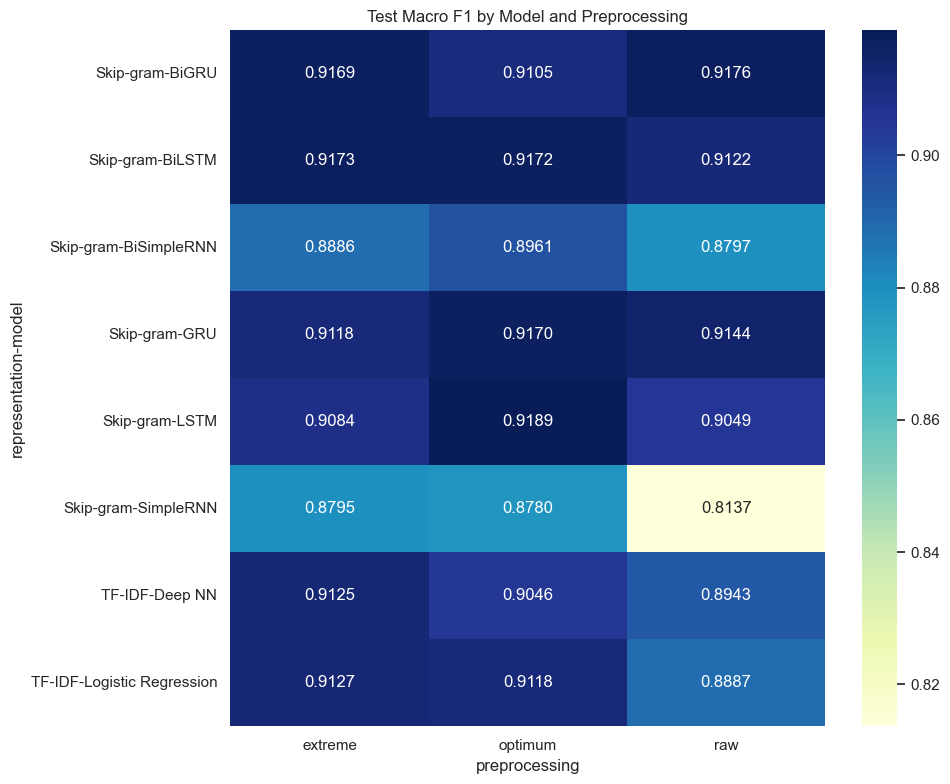

In [38]:
pivot_f1 = results_df.pivot_table(
    index=["representation", "model"],
    columns="preprocessing",
    values="test_macro_f1",
)

display(pivot_f1)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_f1, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Test Macro F1 by Model and Preprocessing")
plt.tight_layout()
plt.show()

,representation,preprocessing,test_macro_f1,group
3,TF-IDF,extreme,0.912571,TF-IDF | extreme
4,TF-IDF,optimum,0.908208,TF-IDF | optimum
1,Skip-gram,optimum,0.906273,Skip-gram | optimum
0,Skip-gram,extreme,0.903749,Skip-gram | extreme
5,TF-IDF,raw,0.891492,TF-IDF | raw
2,Skip-gram,raw,0.890430,Skip-gram | raw


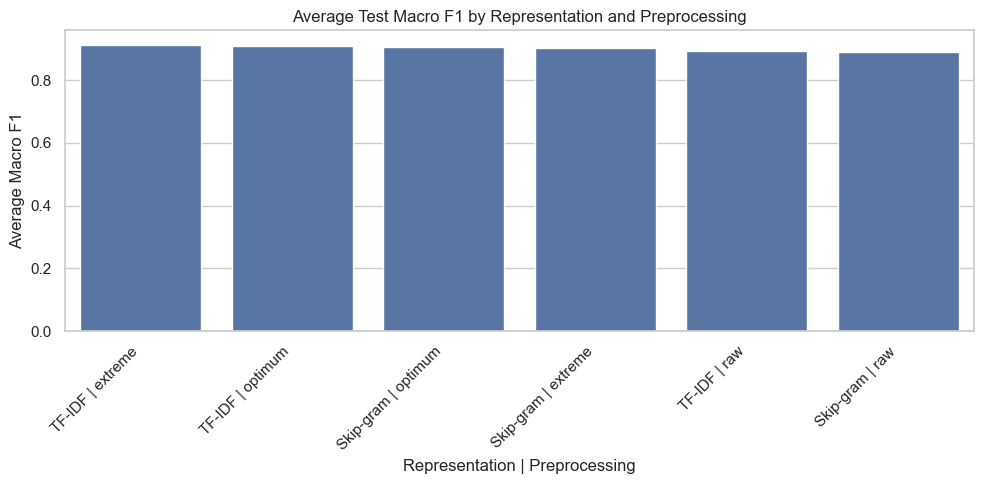

In [39]:
summary_by_representation = (
    results_df.groupby(["representation", "preprocessing"])["test_macro_f1"]
    .mean()
    .reset_index()
    .sort_values("test_macro_f1", ascending=False)
)

summary_by_representation["group"] = (
    summary_by_representation["representation"] + " | " + summary_by_representation["preprocessing"]
)

display(summary_by_representation)

plt.figure(figsize=(10, 5))
sns.barplot(data=summary_by_representation, x="group", y="test_macro_f1")
plt.title("Average Test Macro F1 by Representation and Preprocessing")
plt.xlabel("Representation | Preprocessing")
plt.ylabel("Average Macro F1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [40]:
best_preprocessing = (
    results_df.groupby("preprocessing")["test_macro_f1"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
best_representation = (
    results_df.groupby("representation")["test_macro_f1"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
best_model_group = (
    results_df.groupby(["representation", "model"])["test_macro_f1"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("Average macro F1 by preprocessing")
display(best_preprocessing)

print("Average macro F1 by representation")
display(best_representation)

print("Average macro F1 by model")
display(best_model_group)

Average macro F1 by preprocessing


,preprocessing,test_macro_f1
0,optimum,0.906757
1,extreme,0.905955
2,raw,0.890696


Average macro F1 by representation


,representation,test_macro_f1
0,TF-IDF,0.904090
1,Skip-gram,0.900151


Average macro F1 by model


,representation,model,test_macro_f1
0,Skip-gram,BiLSTM,0.915556
1,Skip-gram,BiGRU,0.914998
2,Skip-gram,GRU,0.914409
3,Skip-gram,LSTM,0.910745
4,TF-IDF,Logistic Regression,0.904391
5,TF-IDF,Deep NN,0.903790
6,Skip-gram,BiSimpleRNN,0.888133
7,Skip-gram,SimpleRNN,0.857065


## 9. Inspect Any Saved Neural History

In [41]:
def show_saved_history(run_name: str):
    history_path = HISTORY_DIR / f"{run_name}_history.csv"
    if not history_path.exists():
        print("No history file found for:", run_name)
        return

    history_df = pd.read_csv(history_path)
    display(history_df)
    save_history_plot(history_df, run_name)
    display(history_df.tail())

## 10. Short Conclusion Notes for the Report

After the full run finishes, summarize:
- which preprocessing version worked best overall
- which representation worked best overall
- the best and worst individual runs
- whether aggressive preprocessing helped or hurt the dataset
- how validation performance matched the final test performance
- why the final hyperparameters were kept for each model